In [ ]:
# Step 6 - EBM Deep Analysis
# Objective 2: Explainable ML - full interpretation of the EBM GlassBox model

# Unlike Step 5 (SHAP on the black-box XGBoost model), EBM is natively interpretable: every prediction is exactly intercept + sum of per-term
# lookups, with no approximation.

# Plan:
#   1. Load the trained EBM pipeline (Step 4) and the same data used to train it
#   2. Rank ALL terms (5,000 main effects + 7 interactions) by global importance
#   3. Attach corrected gene identities (shared TB-Profiler/GFF pipeline, Step 2/5)
#   4. Flag compensatory / primary-DR terms among the top results
#   5. Plot shape functions for the top main-effect terms
#   6. Deep-dive all 7 interaction terms as 2x2 contribution heatmaps
#   7. Cross-check EBM's own top terms against Step 5's SHAP consensus findings
#   8. Local (single-sample) explanation for one MDR and one non-MDR isolate
#   9. Save all outputs and print a final summary


In [1]:
import os, pickle, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

# EBM pipeline was saved with a custom float32-casting transformer as one of its steps. Unpickling requires this exact class to be 
# importable under __main__ with the same name, defining it here before loading the pickle.
class ToFloat32(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):
        return self
    def transform(self, x, y=None):
        return x.astype(np.float32)

import __main__
__main__.ToFloat32 = ToFloat32


In [2]:
HOME   = os.path.expanduser("~")
BASE   = os.path.join(HOME, "tb_pipeline")
ML_OUT = os.path.join(BASE, "ml_outputs")
STEP1  = os.path.join(ML_OUT, "step1_dataset")
STEP4  = os.path.join(ML_OUT, "step4_models")
MODELS = os.path.join(STEP4, "trained_models")
STEP5  = os.path.join(ML_OUT, "step5_shap")
STEP6  = os.path.join(ML_OUT, "step6_ebm")
os.makedirs(STEP6, exist_ok=True)

print(f"Step 4 inputs : {STEP4}")
print(f"Step 5 inputs : {STEP5}")
print(f"Step 6 outputs: {STEP6}")


Step 4 inputs : /home/sukhjot/tb_pipeline/ml_outputs/step4_models
Step 5 inputs : /home/sukhjot/tb_pipeline/ml_outputs/step5_shap
Step 6 outputs: /home/sukhjot/tb_pipeline/ml_outputs/step6_ebm


### Data loading and model

In [3]:
x_data = np.load(os.path.join(STEP1, "X_array.npy"))
y      = np.load(os.path.join(STEP1, "y_mdr_array.npy"))
labels = pd.read_csv(os.path.join(STEP1, "y_labels.csv"))

with open(os.path.join(STEP1, "feature_names_clean.txt")) as f:
    feature_names_full = [line.strip() for line in f if line.strip()]

print(f"X shape: {x_data.shape}")
print(f"y shape: {y.shape}  (MDR={int(y.sum())}, non-MDR={int((y==0).sum())})")
print(f"labels shape: {labels.shape}")
print(f"feature names: {len(feature_names_full):,} (full matrix width)")

X shape: (1858, 94583)
y shape: (1858,)  (MDR=871, non-MDR=987)
labels shape: (1858, 49)
feature names: 94,583 (full matrix width)


In [4]:
assert x_data.shape[0] == y.shape[0], "sample count mismatch between X and y"
assert x_data.shape[1] == len(feature_names_full), "feature count mismatch"

In [5]:
with open(os.path.join(MODELS, "ebm_pipeline.pkl"), "rb") as f:
    ebm_pipe = pickle.load(f)

pipeline = ebm_pipe["pipeline"]
ebm_model = pipeline.named_steps["model"]
chi2_selector = pipeline.named_steps["chi2"]      # SelectKBest(chi2, k=5000), already fit
feature_names = ebm_pipe["feature_names"]         # the 5,000 chi2-selected variant_ids, in the same order EBM's internal

print(f"EBM pipeline steps: {list(pipeline.named_steps.keys())}")
print(f"chi2: {chi2_selector.n_features_in_:,} -> {chi2_selector.get_support().sum():,} features")
print(f"EBM terms (main+interact): {len(ebm_model.term_features_):,}")
print(f"EBM classes_: {ebm_model.classes_}")
print(f"EBM intercept_ (baseline, log-odds scale): {ebm_model.intercept_[0]:.4f}")


EBM pipeline steps: ['chi2', 'f32', 'model']
chi2: 94,583 -> 5,000 features
EBM terms (main+interact): 5,007
EBM classes_: [0 1]
EBM intercept_ (baseline, log-odds scale): -5.1932


In [6]:
n_main = sum(1 for tf in ebm_model.term_features_ if len(tf) == 1)
n_interact = sum(1 for tf in ebm_model.term_features_ if len(tf) == 2)
print(f"Main-effect terms: {n_main:,}")
print(f"Interaction terms: {n_interact}")
assert n_main + n_interact == len(ebm_model.term_features_)
assert n_main == len(feature_names), "one main-effect term expected per chi2-selected feature"


Main-effect terms: 5,000
Interaction terms: 7


### Global term ranking

In [7]:
importances = ebm_model.term_importances()

rows = []
for term_idx, tf in enumerate(ebm_model.term_features_):
    names = [feature_names[j] for j in tf]
    rows.append({
        "term_idx": term_idx,
        "term_type": "interaction" if len(tf) == 2 else "main_effect",
        "n_features": len(tf),
        "feature_a": names[0],
        "feature_b": names[1] if len(names) > 1 else None,
        "importance": importances[term_idx],
    })

terms_df = pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)
terms_df.insert(0, "rank", np.arange(1, len(terms_df) + 1))

out_path = os.path.join(STEP6, "obj2_ebm_all_terms.csv")
terms_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}  ({len(terms_df):,} terms)")

print("\nTop 20 terms by importance:")
print(terms_df.head(20).to_string(index=False))


Saved: /home/sukhjot/tb_pipeline/ml_outputs/step6_ebm/obj2_ebm_all_terms.csv  (5,007 terms)

Top 20 terms by importance:
 rank  term_idx   term_type  n_features              feature_a feature_b  importance
    1      2472 main_effect           1 Chromosome_2155168_C_G      None    1.411866
    2       981 main_effect           1  Chromosome_761155_C_T      None    0.568245
    3       980 main_effect           1  Chromosome_761110_A_T      None    0.481526
    4      2010 main_effect           1 Chromosome_1673425_C_T      None    0.317079
    5      4781 main_effect           1 Chromosome_4247429_A_G      None    0.284212
    6        36 main_effect           1    Chromosome_7570_C_T      None    0.226316
    7      4782 main_effect           1 Chromosome_4247431_G_C      None    0.207868
    8        39 main_effect           1    Chromosome_7582_A_G      None    0.198502
    9      2012 main_effect           1 Chromosome_1674048_G_A      None    0.183634
   10       573 main_effect  

### Gene annotation
Reuses the single shared, corrected gene-annotation table built by Step 2 (`comparative_analysis.py`) and already consumed by Step 5, TB-Profiler's own calls first, reference-GFF fallback second. Loading directly, so that gene identity doesnot collide.

In [8]:
GENE_ANNOTATION_PATH = os.path.join(STEP1, "variant_metadata_with_genes.csv")
vm_genes = pd.read_csv(GENE_ANNOTATION_PATH)
GENE_LOOKUP = vm_genes.set_index("variant_id")[
    ["gene", "gene_source", "is_compensatory", "is_primary_DR"]
].to_dict("index")

def annotate_variant(variant_id):
    info = GENE_LOOKUP.get(variant_id)
    if info is None:
        return "intergenic", "none", 0, 0
    return info["gene"], info["gene_source"], info["is_compensatory"], info["is_primary_DR"]

def annotate_term(row):
    """Works for both main-effect (feature_b is None) and interaction terms."""
    gene_a, src_a, comp_a, dr_a = annotate_variant(row["feature_a"])
    if row["feature_b"] is None:
        return pd.Series({
            "gene_a": gene_a, "gene_b": None,
            "is_compensatory": comp_a, "is_primary_DR": dr_a,
            "gene_source_a": src_a, "gene_source_b": None,
        })
    gene_b, src_b, comp_b, dr_b = annotate_variant(row["feature_b"])
    return pd.Series({
        "gene_a": gene_a, "gene_b": gene_b,
        # an interaction term counts as compensatory/primary-DR if EITHER side does
        "is_compensatory": int(bool(comp_a) or bool(comp_b)),
        "is_primary_DR": int(bool(dr_a) or bool(dr_b)),
        "gene_source_a": src_a, "gene_source_b": src_b,
    })

top100 = terms_df.head(100).copy()
top100 = pd.concat([top100, top100.apply(annotate_term, axis=1)], axis=1)

out_path = os.path.join(STEP6, "obj2_ebm_top100_annotated.csv")
top100.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print("\nGene distribution in top 100 EBM terms (main effects only, top 15):")
print(top100.loc[top100["term_type"]=="main_effect", "gene_a"].value_counts().head(15).to_string())


Saved: /home/sukhjot/tb_pipeline/ml_outputs/step6_ebm/obj2_ebm_top100_annotated.csv

Gene distribution in top 100 EBM terms (main effects only, top 15):
gene_a
intergenic    10
Rv0278c        5
gyrA           4
inhA           3
PE_PGRS53      3
pks12          3
rpoB           3
fadD2          2
PE_PGRS10      2
embB           2
rpsL           2
rrs            2
katG           1
PE_PGRS5       1
PPE55          1


### Compensatory and primary-DR terms in the top 100

In [9]:
comp_ebm = top100[top100["is_compensatory"] == 1]
dr_ebm   = top100[top100["is_primary_DR"] == 1]

print(f"Compensatory-gene terms in EBM top 100 : {len(comp_ebm)}")
print(f"Primary-DR-gene terms in EBM top 100   : {len(dr_ebm)}")

if len(comp_ebm) > 0:
    print("\nCompensatory terms:")
    print(comp_ebm[["rank","term_type","feature_a","feature_b","gene_a","gene_b","importance"]].to_string(index=False))

comp_path = os.path.join(STEP6, "obj2_ebm_compensatory_features.csv")
comp_ebm.to_csv(comp_path, index=False)
print(f"\nSaved: {comp_path}")


Compensatory-gene terms in EBM top 100 : 0
Primary-DR-gene terms in EBM top 100   : 18

Saved: /home/sukhjot/tb_pipeline/ml_outputs/step6_ebm/obj2_ebm_compensatory_features.csv


### Shape functions - top main-effect terms
Every feature is binary (variant present/absent), so an EBM shape function here is exactly two values: the contribution when the variant is absent (0) and when it is present (1), plus the model's own confidence bounds around each.

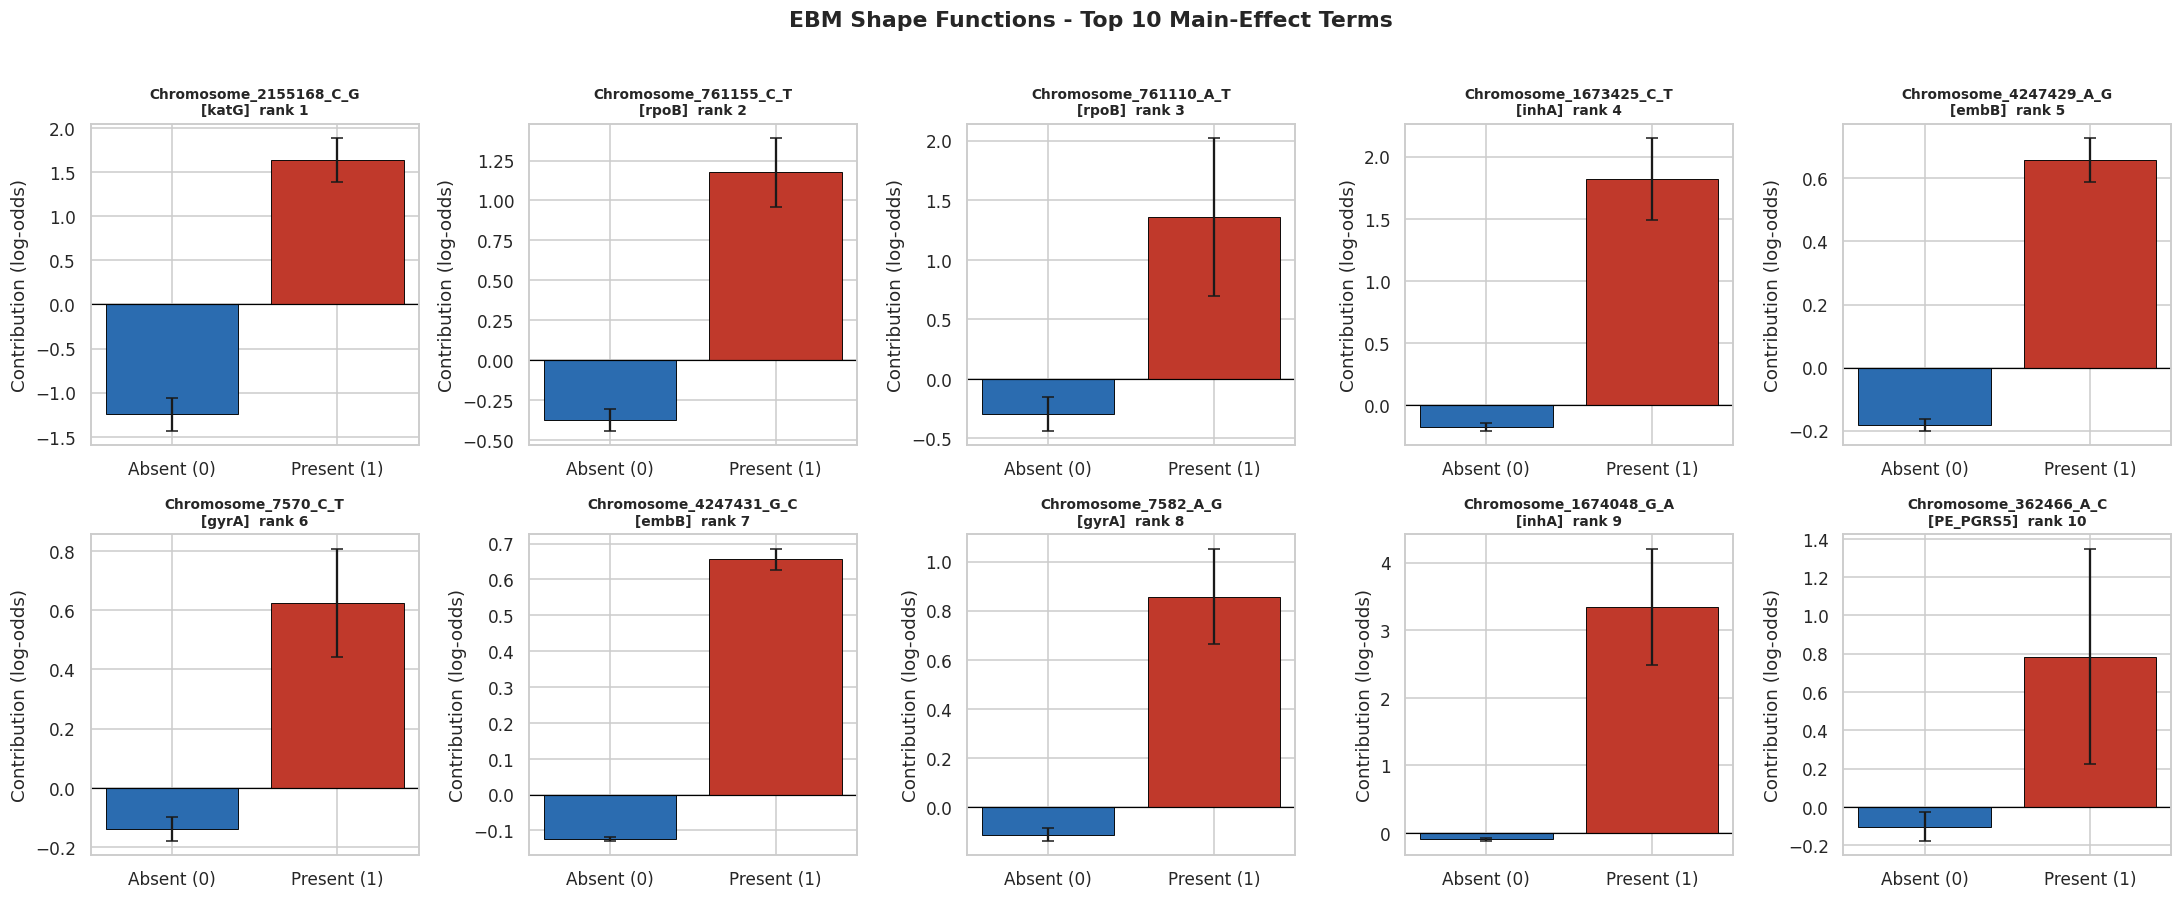

Saved: /home/sukhjot/tb_pipeline/ml_outputs/step6_ebm/obj2_ebm_shape_functions_top10.png


In [10]:
N_SHOW = 10
main_effects = terms_df[terms_df["term_type"] == "main_effect"].head(N_SHOW).copy()
ebm_global = ebm_model.explain_global()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, main_effects.iterrows()):
    d = ebm_global.data(int(row["term_idx"]))
    scores = d["scores"]                 # [score_absent, score_present]
    lower  = d["lower_bounds"]
    upper  = d["upper_bounds"]
    errs   = [[scores[i]-lower[i] for i in range(2)], [upper[i]-scores[i] for i in range(2)]]

    colors = ["#2b6cb0" if s < 0 else "#c0392b" for s in scores]
    ax.bar(["Absent (0)", "Present (1)"], scores, yerr=errs, color=colors,
           capsize=4, edgecolor="black", linewidth=0.6)
    ax.axhline(0, color="black", linewidth=0.8)
    gene_a, _, _, _ = annotate_variant(row["feature_a"])
    ax.set_title(f"{row['feature_a']}\n[{gene_a}]  rank {row['rank']}", fontsize=9)
    ax.set_ylabel("Contribution (log-odds)")

plt.suptitle("EBM Shape Functions - Top 10 Main-Effect Terms", fontweight="bold", y=1.02)
plt.tight_layout()
out_path = os.path.join(STEP6, "obj2_ebm_shape_functions_top10.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


### Interaction terms - deep dive
All 7 interaction terms EBM learned, each visualised as a 2x2 grid: the model's contribution for every combination of (feature A present/absent) x (feature B present/absent). This replaces the original, incorrect rpoC x rpoB / kasA x katG framing from the pre-correction Phase 4A report -- the actual gene pairs, verified against the corrected annotation, are shown directly on each panel.

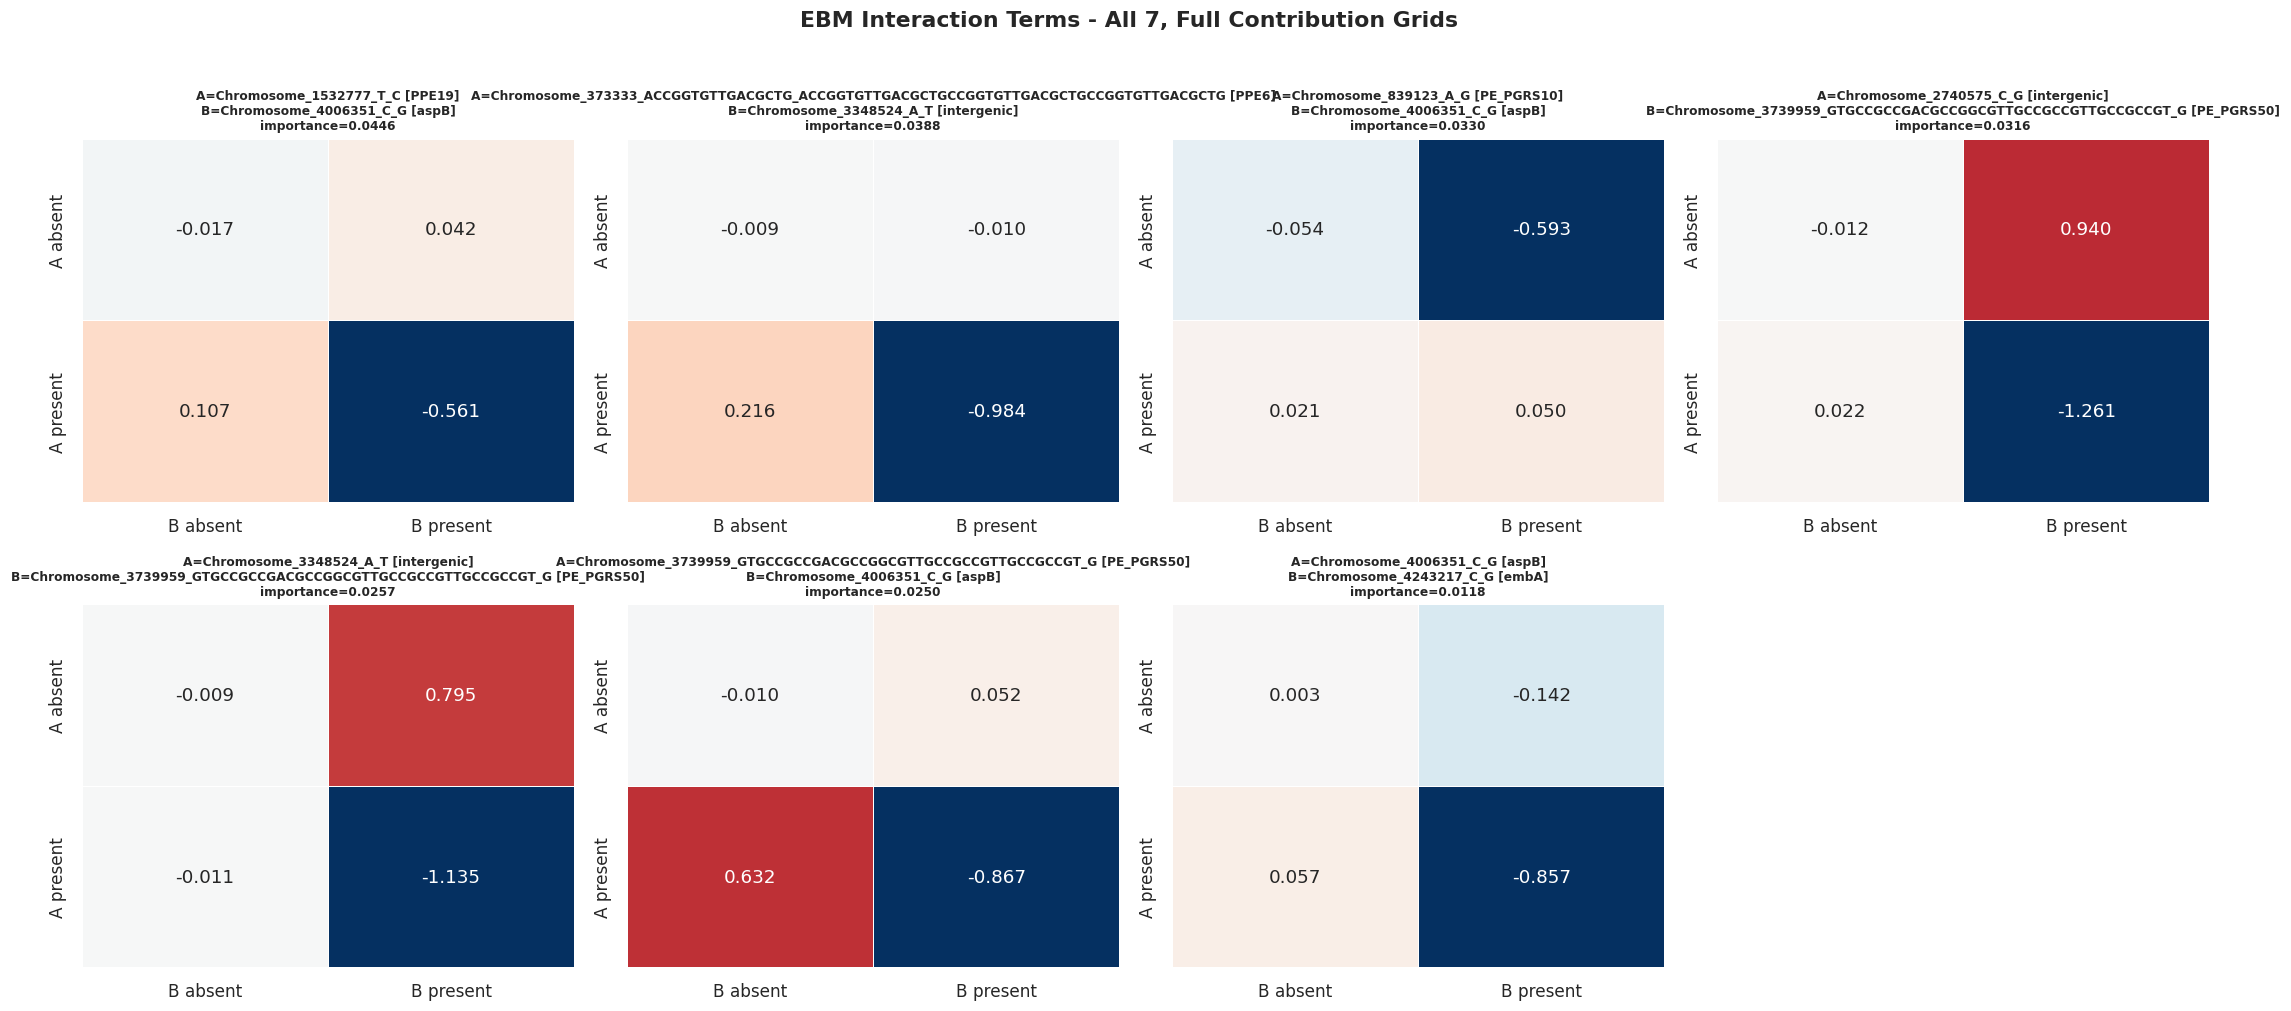

Saved: /home/sukhjot/tb_pipeline/ml_outputs/step6_ebm/obj2_ebm_interaction_heatmaps.png
Saved: /home/sukhjot/tb_pipeline/ml_outputs/step6_ebm/obj2_ebm_interactions_annotated.csv

 rank                                                                         feature_a     gene_a                                                  feature_b     gene_b  importance  is_compensatory  is_primary_DR
  217                                                            Chromosome_1532777_T_C      PPE19                                     Chromosome_4006351_C_G       aspB    0.044570                0              0
  337 Chromosome_373333_ACCGGTGTTGACGCTG_ACCGGTGTTGACGCTGCCGGTGTTGACGCTGCCGGTGTTGACGCTG       PPE6                                     Chromosome_3348524_A_T intergenic    0.038792                0              0
  437                                                             Chromosome_839123_A_G  PE_PGRS10                                     Chromosome_4006351_C_G       aspB    0.033000  

In [11]:
interactions = terms_df[terms_df["term_type"] == "interaction"].sort_values("importance", ascending=False).copy()
interactions = pd.concat([interactions, interactions.apply(annotate_term, axis=1)], axis=1)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

interaction_rows = []
for ax, (_, row) in zip(axes, interactions.iterrows()):
    d = ebm_global.data(int(row["term_idx"]))
    grid = np.array(d["scores"])   # shape (2,2): [ [both-absent, A-absent/B-present],
                                    #               [A-present/B-absent, both-present] ]
    sns.heatmap(grid, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax,
                xticklabels=["B absent", "B present"], yticklabels=["A absent", "A present"],
                cbar=False, linewidths=0.5, linecolor="white")
    ax.set_title(f"A={row['feature_a']} [{row['gene_a']}]\n"
                 f"B={row['feature_b']} [{row['gene_b']}]\n"
                 f"importance={row['importance']:.4f}", fontsize=8)

    both_absent, a_only  = grid[0, 0], grid[1, 0]
    b_only, both_present = grid[0, 1], grid[1, 1]
    interaction_rows.append({
        "rank": row["rank"], "feature_a": row["feature_a"], "gene_a": row["gene_a"],
        "feature_b": row["feature_b"], "gene_b": row["gene_b"],
        "importance": row["importance"],
        "is_compensatory": row["is_compensatory"], "is_primary_DR": row["is_primary_DR"],
        "score_both_absent": both_absent, "score_A_only": a_only,
        "score_B_only": b_only, "score_both_present": both_present,
    })

# 7 interactions, 8 subplot slots and hiding the unused one
for ax in axes[len(interactions):]:
    ax.axis("off")

plt.suptitle("EBM Interaction Terms - All 7, Full Contribution Grids", fontweight="bold", y=1.02)
plt.tight_layout()
out_path = os.path.join(STEP6, "obj2_ebm_interaction_heatmaps.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

interactions_out = pd.DataFrame(interaction_rows)
csv_path = os.path.join(STEP6, "obj2_ebm_interactions_annotated.csv")
interactions_out.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")
print()
print(interactions_out[["rank","feature_a","gene_a","feature_b","gene_b","importance",
                         "is_compensatory","is_primary_DR"]].to_string(index=False))


### Cross-check against Step 5's SHAP findings
Does EBM's own top-ranked terms agree with what SHAP found important for XGBoost? Loads Step 5's outputs directly rather than recomputing anything.

In [12]:
shap_top100_path = os.path.join(STEP5, "obj2_shap_top100_annotated.csv")
if os.path.exists(shap_top100_path):
    shap_top100 = pd.read_csv(shap_top100_path)
    shap_ids = set(shap_top100["variant_id"])

    ebm_main_top100 = top100[top100["term_type"] == "main_effect"]
    overlap = ebm_main_top100[ebm_main_top100["feature_a"].isin(shap_ids)]

    print(f"EBM top-100 main effects also in SHAP top-100 (XGBoost): "
          f"{len(overlap)} / {len(ebm_main_top100)}")
    if len(overlap) > 0:
        print(overlap[["rank","feature_a","gene_a","importance"]].to_string(index=False))

    crosscheck_path = os.path.join(STEP6, "obj2_ebm_shap_crosscheck.csv")
    overlap.to_csv(crosscheck_path, index=False)
    print(f"\nSaved: {crosscheck_path}")
else:
    print(f"Step 5 output not found at {shap_top100_path} - skipping cross-check. "
          f"Run shap_analysis.ipynb first if this is unexpected.")


EBM top-100 main effects also in SHAP top-100 (XGBoost): 24 / 100
 rank                                                 feature_a     gene_a  importance
    1                                    Chromosome_2155168_C_G       katG    1.411866
    2                                     Chromosome_761155_C_T       rpoB    0.568245
    3                                     Chromosome_761110_A_T       rpoB    0.481526
    4                                    Chromosome_1673425_C_T       inhA    0.317079
    5                                    Chromosome_4247429_A_G       embB    0.284212
    6                                       Chromosome_7570_C_T       gyrA    0.226316
    7                                    Chromosome_4247431_G_C       embB    0.207868
    8                                       Chromosome_7582_A_G       gyrA    0.198502
    9                                    Chromosome_1674048_G_A       inhA    0.183634
   13                                    Chromosome_1644362_C_T 

### Local (single-sample) explanation
EBM's local explanation is exactly additive by construction -- unlike SHAP, which is a game-theoretic *approximation* extracted from an otherwise black-box model, EBM's prediction for a sample literally *is* `intercept + sum(each term's looked-up contribution for that sample)`. Same two isolates as Step 5's waterfall plot, for direct comparison.

MDR Sample - SRR30519414: intercept + sum(all 5007 term scores) = 1.258643  -> sigmoid = 0.778792  vs pipeline.predict_proba(class=1) = 0.778792  (match: True)
non-MDR Sample - SRR11922476: intercept + sum(all 5007 term scores) = -6.911967  -> sigmoid = 0.000995  vs pipeline.predict_proba(class=1) = 0.000995  (match: True)


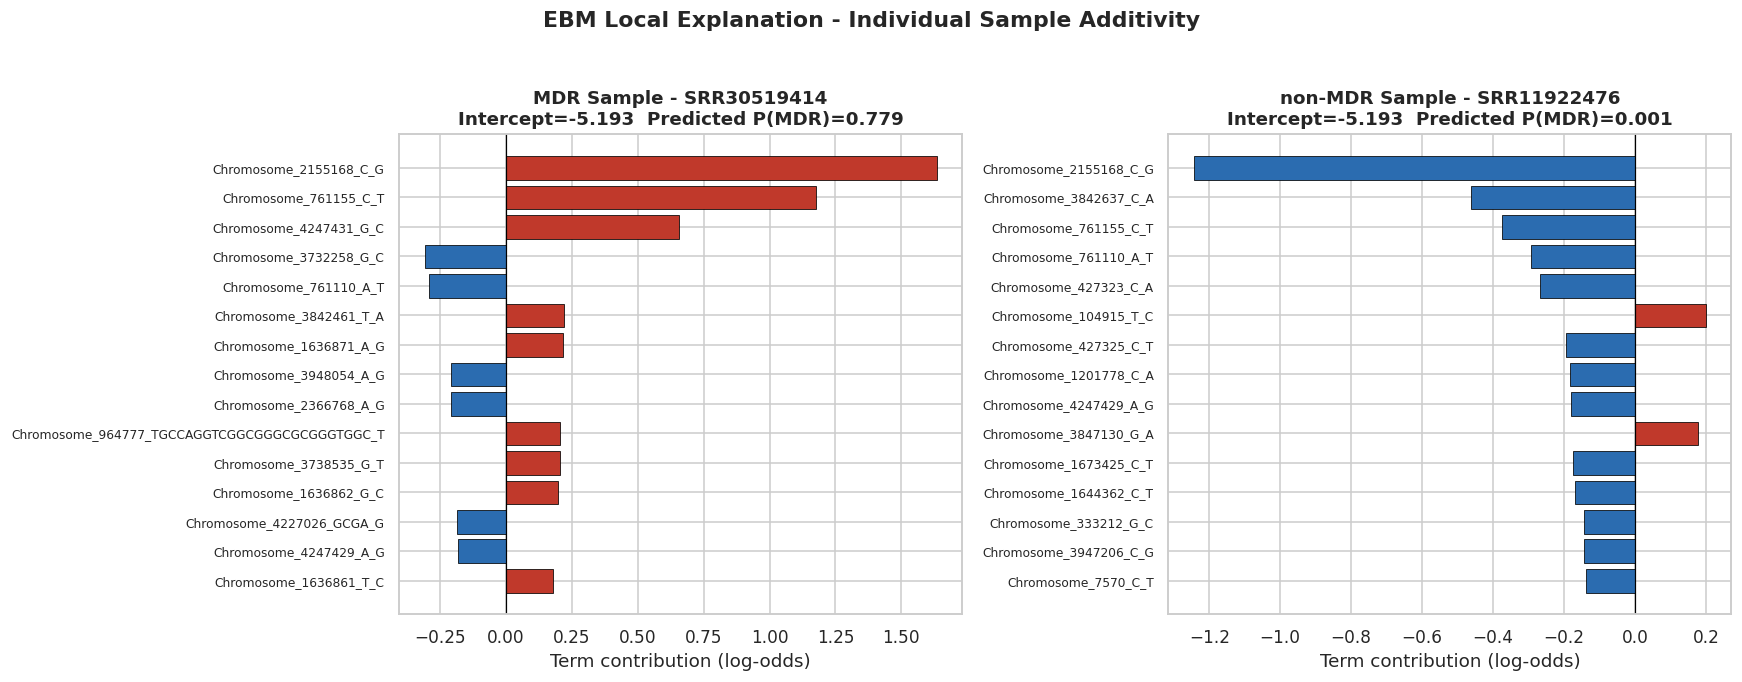


Saved: /home/sukhjot/tb_pipeline/ml_outputs/step6_ebm/obj2_ebm_local_explanation.png


In [13]:
idx_mdr    = int(np.where(y == 1)[0][0])
idx_nonmdr = int(np.where(y == 0)[0][0])
sample_ids = labels["sample_id"] if "sample_id" in labels.columns else labels.iloc[:, 0]

X_pick = x_data[[idx_mdr, idx_nonmdr]]
y_pick = y[[idx_mdr, idx_nonmdr]]
X_sel  = chi2_selector.transform(X_pick).astype(np.float32)

local_exp = ebm_model.explain_local(X_sel, y_pick)
proba_class1 = pipeline.predict_proba(X_pick)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
titles = [f"MDR Sample - {sample_ids.iloc[idx_mdr]}", f"non-MDR Sample - {sample_ids.iloc[idx_nonmdr]}"]

for ax, i, title in zip(axes, range(2), titles):
    d = local_exp.data(i)
    term_scores = np.array(d["scores"])
    intercept   = d["extra"]["scores"][0]

    # resolve to real variant_id / gene labels using the same term ordering as terms_df
    resolved = []
    for tidx, tf in enumerate(ebm_model.term_features_):
        names = [feature_names[j] for j in tf]
        resolved.append(" & ".join(names))

    order = np.argsort(np.abs(term_scores))[-15:]   # top 15 by |contribution| for this sample
    labels_plot = [resolved[j] for j in order]
    vals = term_scores[order]
    colors = ["#c0392b" if v > 0 else "#2b6cb0" for v in vals]

    ax.barh(range(len(vals)), vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labels_plot, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{title}\nIntercept={intercept:.3f}  Predicted P(MDR)={proba_class1[i]:.3f}")
    ax.set_xlabel("Term contribution (log-odds)")

    checksum = intercept + term_scores.sum()
    sigmoid_checksum = 1 / (1 + np.exp(-checksum))
    print(f"{title}: intercept + sum(all {len(term_scores)} term scores) = {checksum:.6f}  "
          f"-> sigmoid = {sigmoid_checksum:.6f}  vs pipeline.predict_proba(class=1) = {proba_class1[i]:.6f}  "
          f"(match: {np.isclose(sigmoid_checksum, proba_class1[i])})")

plt.suptitle("EBM Local Explanation - Individual Sample Additivity", fontweight="bold", y=1.03)
plt.tight_layout()
out_path = os.path.join(STEP6, "obj2_ebm_local_explanation.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {out_path}")


### Summary

In [14]:
print("STEP 6 COMPLETE - EBM DEEP ANALYSIS")
print(f"Total EBM terms analysed: {len(terms_df):,} ({n_main:,} main effects + {n_interact} interactions)")
print(f"Compensatory terms (top100): {len(comp_ebm)}")
print(f"Primary-DR terms (top100): {len(dr_ebm)}")
print(f"Interaction gene pairs     :")
for _, r in interactions_out.iterrows():
    print(f"    {r['gene_a']} x {r['gene_b']}  (importance={r['importance']:.4f}, "
          f"compensatory={bool(r['is_compensatory'])}, primary_DR={bool(r['is_primary_DR'])})")

print(f"\nOutput files in {STEP6}:")
for fn in sorted(os.listdir(STEP6)):
    fp = os.path.join(STEP6, fn)
    size_kb = os.path.getsize(fp) / 1024
    print(f"  {fn:<45} {size_kb:>10.1f} KB")



STEP 6 COMPLETE - EBM DEEP ANALYSIS
Total EBM terms analysed: 5,007 (5,000 main effects + 7 interactions)
Compensatory terms (top100): 0
Primary-DR terms (top100): 18
Interaction gene pairs     :
    PPE19 x aspB  (importance=0.0446, compensatory=False, primary_DR=False)
    PPE6 x intergenic  (importance=0.0388, compensatory=False, primary_DR=False)
    PE_PGRS10 x aspB  (importance=0.0330, compensatory=False, primary_DR=False)
    intergenic x PE_PGRS50  (importance=0.0316, compensatory=False, primary_DR=False)
    intergenic x PE_PGRS50  (importance=0.0257, compensatory=False, primary_DR=False)
    PE_PGRS50 x aspB  (importance=0.0250, compensatory=False, primary_DR=False)
    aspB x embA  (importance=0.0118, compensatory=False, primary_DR=True)

Output files in /home/sukhjot/tb_pipeline/ml_outputs/step6_ebm:
  obj2_ebm_all_terms.csv                             337.1 KB
  obj2_ebm_compensatory_features.csv                   0.1 KB
  obj2_ebm_interaction_heatmaps.png                 